In [1]:
import os
import shutil
import numpy as np
import sys
# from utils import setup_latex_environment
# setup_latex_environment()
import matplotlib
import pandas as pd
import seaborn as sns
import io
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from tueplots import bundles
plt.style.use(bundles.icml2022())
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{amsfonts}"
})
%matplotlib inline

/tmp/ipykernel_2234589/1161980668.py:38: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


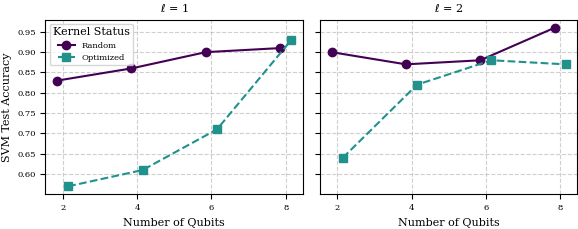

In [2]:
df = pd.read_csv("../results/mnist_chebyshev/results.csv")

fig, axes = plt.subplots(1, 2, figsize=(6, 2.5), sharey=True)
layers = [1, 2]
dodge_offset = 0.15  # How much to shift points left/right

# 3. Loop through layers to create each plot
for i, n_layer in enumerate(layers):
    ax = axes[i]
    # Filter data for the specific number of layers
    df_layer = df[df['n_layers'] == n_layer].sort_values('n_qubits')
    
    # Split between Learnt and Not Learnt
    learnt = df_layer[df_layer['train_kernel'] == True]
    not_learnt = df_layer[df_layer['train_kernel'] == False]
    
    # Plot "Not Learnt" (Fixed)
    ax.plot(not_learnt['n_qubits'] - dodge_offset, not_learnt['test_accuracy'], 
            marker='o', linestyle='-', color='#440154', label='Random')
    
    # Plot "Learnt" (Optimized)
    ax.plot(learnt['n_qubits'] + dodge_offset, learnt['test_accuracy'], 
            marker='s', linestyle='--', color='#21918c', label='Optimized')
    
    # Formatting
    ax.set_title(f"$\ell$ = {n_layer}")
    ax.set_xlabel("Number of Qubits")
    ax.set_xticks(df['n_qubits'].unique())
    ax.grid(True, linestyle='--', alpha=0.6)
    
    if i == 0:
        ax.set_ylabel("SVM Test Accuracy")
    
    # Show legend only on the first plot to avoid clutter
    if i == 0:
        ax.legend(title="Kernel Status")

plt.tight_layout()
plt.show()